# **MACHINE LEARNING COURSE**

Lets see the steps involved in making a machine learning model.
1. Problem definition
2. Data collection
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing / Cleaning
5. Feature Selection & Engineering
6. Split the Dataset
7. Model Selection
8. Model Training
9. Model Evaluation
10. Hyperparameter Tuning
11. Model Testing / Validation

## **Importing Libraries & Data Collection**

**Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

**Data Loading**

In [ ]:
df = pd.read_csv('/content/insurance_synthetic_dataset.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,20.0,male,28.619,1,no,southwest,11915.47089
1,59.0,male,20.976,5,no,southeast,16904.22892
2,59.0,female,29.259,1,no,southeast,21054.85208
3,20.0,female,31.071,0,no,northeast,11590.85225
4,27.0,FEMALE,40.684,0,yes,southwest,36845.73442
...,...,...,...,...,...,...,...
5025,37.0,male,22.712,0,yes,NaN,37611.68989
5026,47.0,female,21.752,0,no,southeast,15998.42826
5027,46.0,female,24.321,0,no,northwest,16229.95959
5028,34.0,male,30.700,1,no,northwest,13709.85084


> **Note:** In this data `charges` is our continuous target variable.

## **EDA - Exploratory Data Analysis**

*Just get the understanding of data, no need to manipulate data in this step.*

### **Basic EDA**

In [ ]:
df.shape

(5030, 7)

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,20.0,male,28.619,1,no,southwest,11915.47089
1,59.0,male,20.976,5,no,southeast,16904.22892
2,59.0,female,29.259,1,no,southeast,21054.85208
3,20.0,female,31.071,0,no,northeast,11590.85225
4,27.0,FEMALE,40.684,0,yes,southwest,36845.73442


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5030 entries, 0 to 5029
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       4990 non-null   float64
 1   sex       5030 non-null   object 
 2   bmi       4969 non-null   float64
 3   children  5030 non-null   int64  
 4   smoker    5030 non-null   object 
 5   region    5005 non-null   object 
 6   charges   5000 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 275.2+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,4990.000000,4969.000000,5030.000000,5000.000000
mean,38.145090,31.022798,1.115507,19627.450043
std,15.417143,6.796451,1.210569,10695.719951
min,-1.000000,-12.000000,0.000000,-42073.340300
25%,24.000000,26.764000,0.000000,12295.046487
50%,37.000000,31.044000,1.000000,16712.100905
75%,51.000000,35.288000,2.000000,22982.177707
max,130.000000,88.500000,5.000000,57829.666090


In [ ]:
df.isnull().sum()
# df.isna().sum()

,0
age,40
sex,0
bmi,61
children,0
smoker,0
region,25
charges,30


In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

### **EDA by Visualization**

In [ ]:
numeric_columns = ['age', 'bmi', 'children', 'charges']
categorical_columns = ['sex', 'smoker', 'region']

**Numeric Columns Distribution**

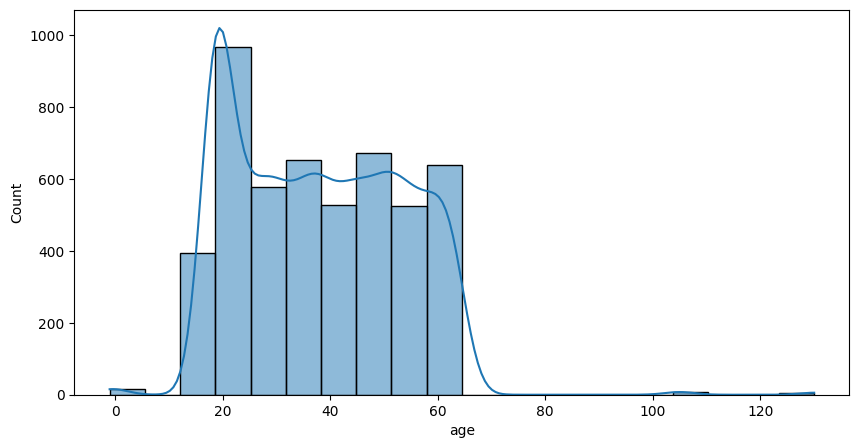

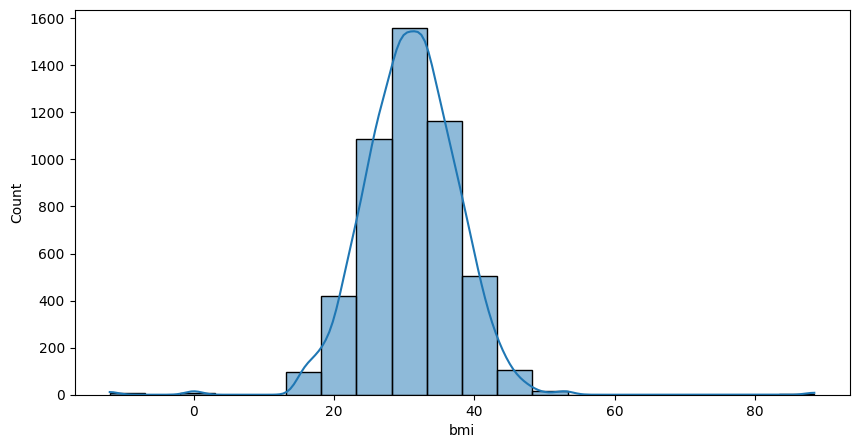

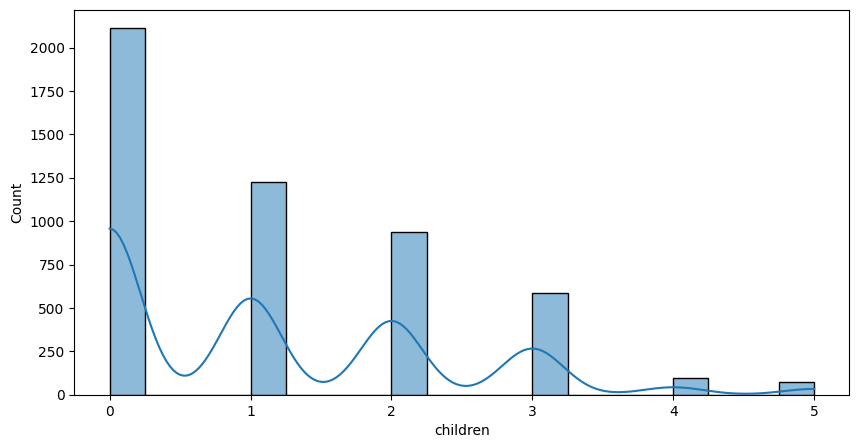

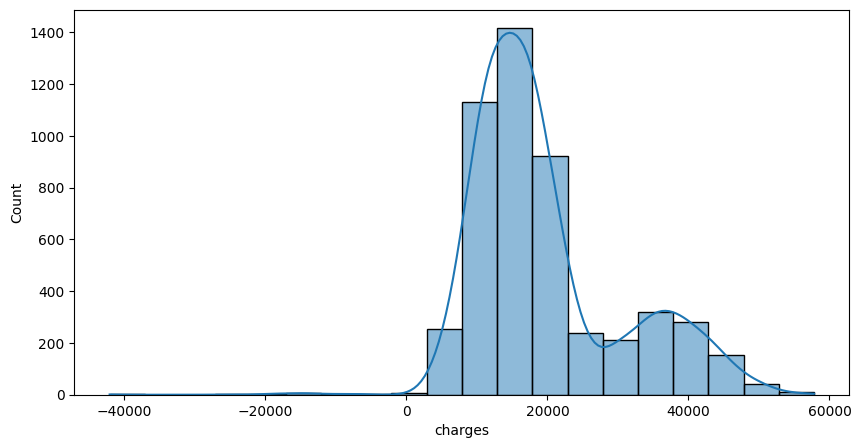

In [ ]:
for col in numeric_columns:
  plt.figure(figsize=(10,5))
  sns.histplot(df[col], kde=True, bins=20)
  plt.show()

**Categorical Columns Distribution**

<Axes: xlabel='children', ylabel='count'>

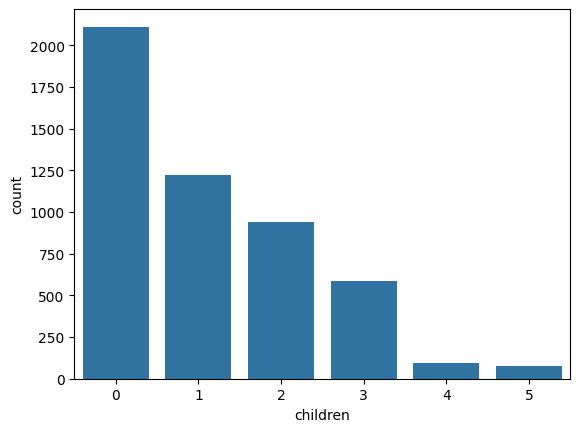

In [ ]:
sns.countplot(x=df['children'])

*We examine `children` because it is a categorical variable encoded as numeric values.*


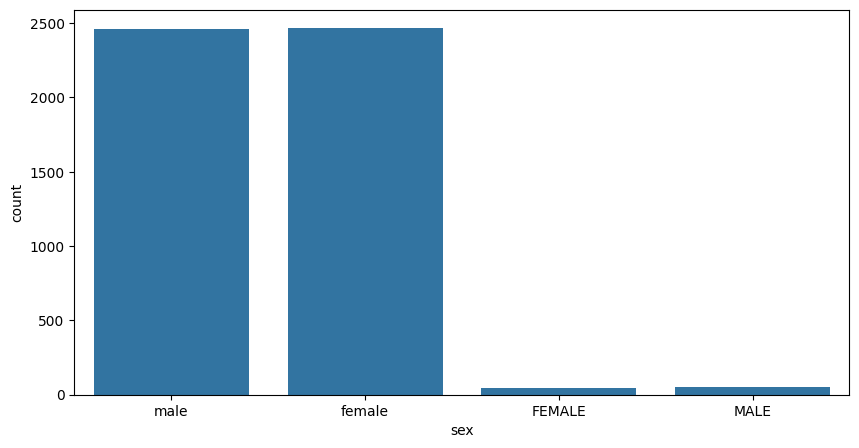

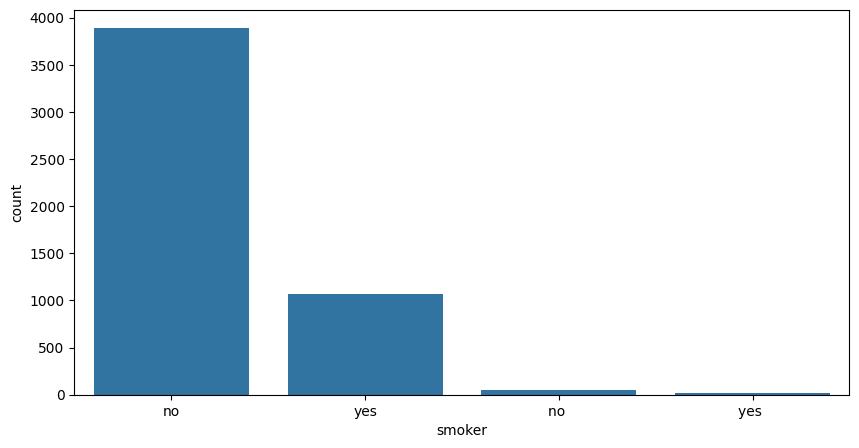

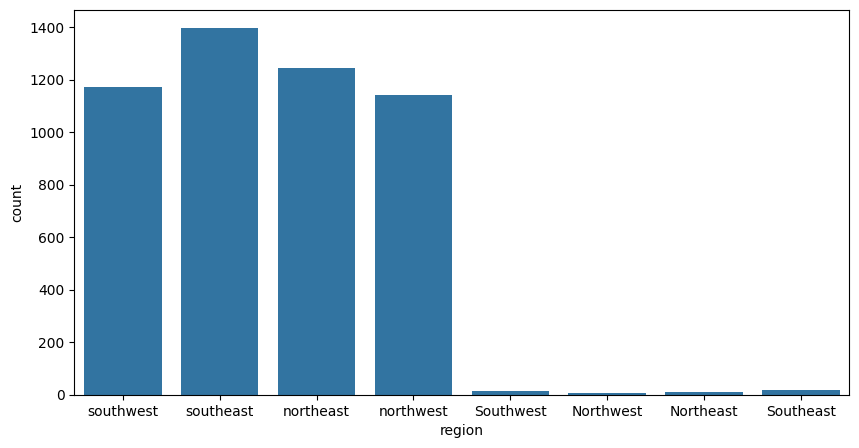

In [ ]:
for col in categorical_columns:
  plt.figure(figsize=(10,5))
  sns.countplot(x=df[col])
  plt.show()

> **Note:** Some variables appear repeated because the dataset hasn't been cleaned yet. Inconsistent naming and sentence casing cause identical features to be treated as separate variables.


**Outliers Distribution**

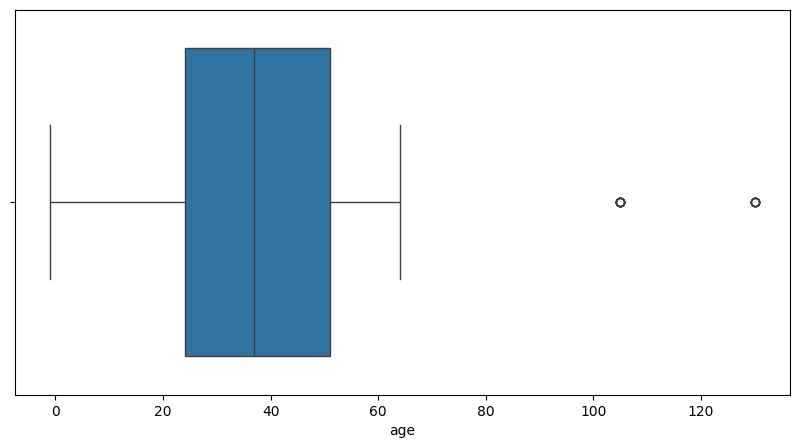

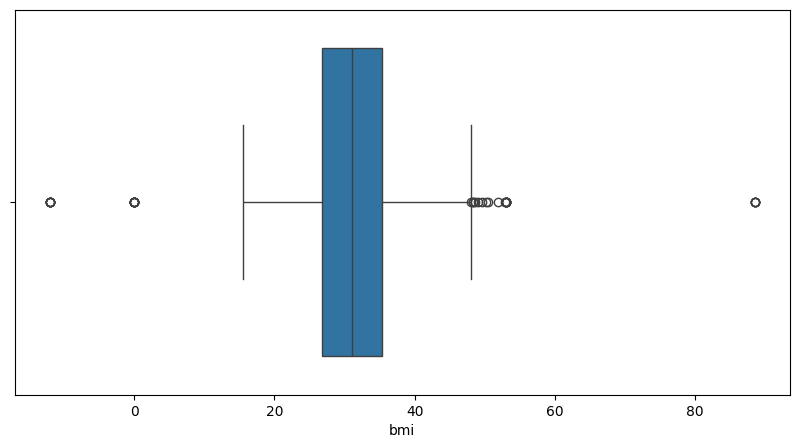

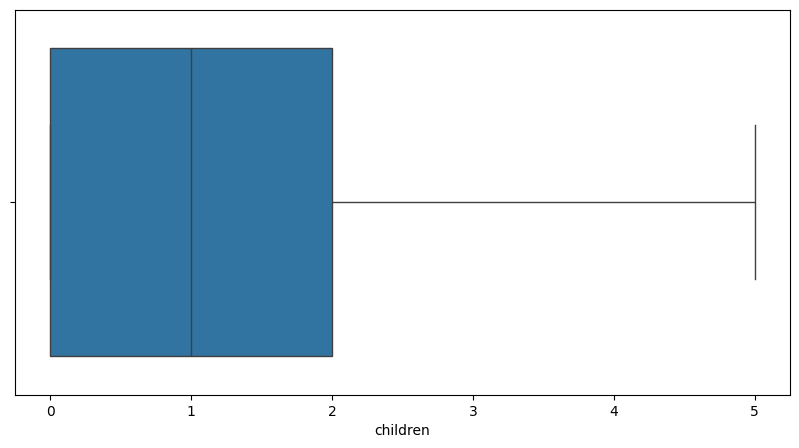

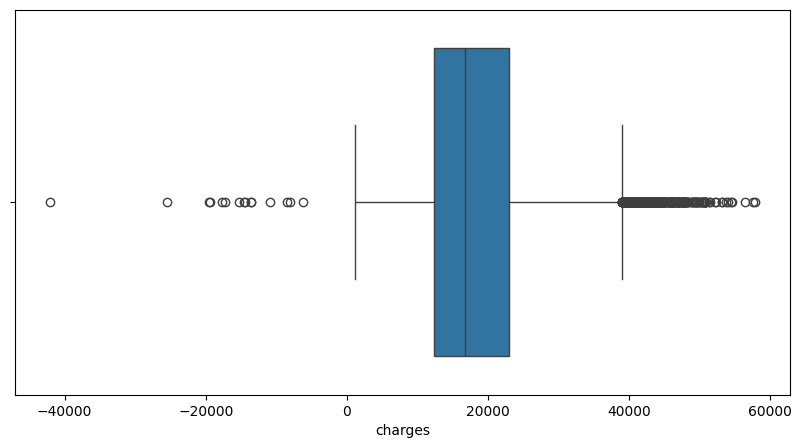

In [ ]:
for col in numeric_columns:
  plt.figure(figsize=(10,5))
  sns.boxplot(x=df[col])
  plt.show()

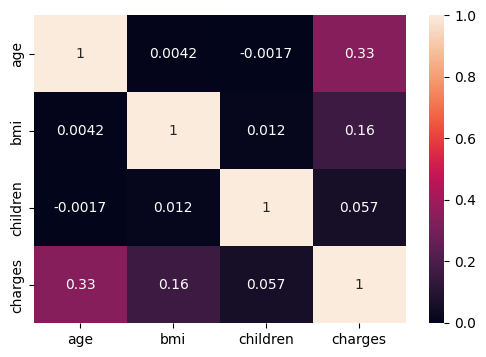

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

## **Data Cleaning**

Quick Rule
* Mean → Continuous + Normal Distribution
* Median → Continuous + Skewed / Outliers
* Mode → Categorical or Encoded Categorical Variables

In [ ]:
df_clean = df.copy()

**Handle Missing Values**

In [ ]:
df.isna().sum()

,0
age,40
sex,0
bmi,61
children,0
smoker,0
region,25
charges,30


In [ ]:
df_clean['age'] = df['age'].fillna(np.mean(df['age']))

df_clean['bmi'] = df['bmi'].fillna(np.mean(df['bmi']))

df_clean['children'] = df['children'].fillna(df['children'].mode()[0])

df_clean['region'] =df['region'].fillna(df['region'].mode()[0])

df_clean['charges'] = df['charges'].fillna(np.median(df['charges']))

In [ ]:
df_clean.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,30


> `charges` still contains 30 missing values because `np.median()` does not ignore `NaN` values. Since the missing values are included in the calculation, the computed median becomes `NaN`, so `fillna()` ends up replacing `NaN` with `NaN`, leaving the missing values unchanged.



Reason:

- `np.median()` → NaN ko ignore nahi karta.
- `df['charges'].median()` → NaN ko automatically ignore karta.
- `np.nanmedian()` → NaN ko ignore karta.

In [ ]:
df_clean['charges'] = df['charges'].fillna(np.nanmedian(df['charges']))

In [ ]:
df_clean.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,20.0,male,28.619,1,no,southwest,11915.47089
1,59.0,male,20.976,5,no,southeast,16904.22892
2,59.0,female,29.259,1,no,southeast,21054.85208
3,20.0,female,31.071,0,no,northeast,11590.85225
4,27.0,FEMALE,40.684,0,yes,southwest,36845.73442


In [ ]:
df_clean.shape

(5030, 7)

**Remove Duplicates**

In [ ]:
df_clean.duplicated().sum()

np.int64(30)

In [ ]:
df_clean.drop_duplicates(inplace=True)

In [ ]:
df_clean.shape

(5000, 7)

In [ ]:
df_clean.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


**Fix Data Types**

In [ ]:
df_clean.dtypes

,0
age,float64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


**Handling Inconsistent Categories**

Now, let's resolve the case-sensitivity issue we encountered earlier.

In [ ]:
df_clean['sex'].value_counts()

,count
sex,
female,2452
male,2448
MALE,52
FEMALE,48


In [ ]:
# def convert_to_lower(text):
#   return text.lower()

In [ ]:
# df_clean['sex'] = df_clean['sex'].apply(convert_to_lower)

# df_clean['sex'] = df_clean['sex'].apply(lambda x: x.lower())

In [ ]:
df_clean['sex'] = df_clean['sex'].str.lower()

In [ ]:
df_clean['sex'].value_counts()

,count
sex,
male,2500
female,2500


In [ ]:
df_clean['smoker'].value_counts()

,count
smoker,
no,3869
yes,1056
no,54
yes,21


This usually happens because of one of these reasons:
- Leading/trailing spaces: `"yes "` vs `"yes"`
- Hidden whitespace: `" yes"` vs `"yes"`
- Different capitalization: `"Yes"` vs `"yes"`

In [ ]:
df_clean['smoker'].unique()

array(['no', 'yes', 'no ', 'yes '], dtype=object)

In [ ]:
df_clean['smoker'] = df_clean['smoker'].str.strip().str.lower()     # Remove leading/trailing spaces & Convert to lowercase

In [ ]:
df_clean['smoker'].value_counts()

,count
smoker,
no,3923
yes,1077


In [ ]:
df_clean['region'].value_counts()

,count
region,
southeast,1414
northeast,1235
southwest,1162
northwest,1139
Southeast,17
Southwest,14
Northeast,12
Northwest,7


In [ ]:
df_clean['region'] = df_clean['region'].str.lower()

In [ ]:
df_clean['region'].value_counts()

,count
region,
southeast,1431
northeast,1247
southwest,1176
northwest,1146


**Detect & Handle Outliers**

Methods:
1. Trimming (Dropping / Removal)
2. Capping (Winsorization)
3. Imputation (Replacement)
4. Data Transformation

**Age**

<Axes: xlabel='age'>

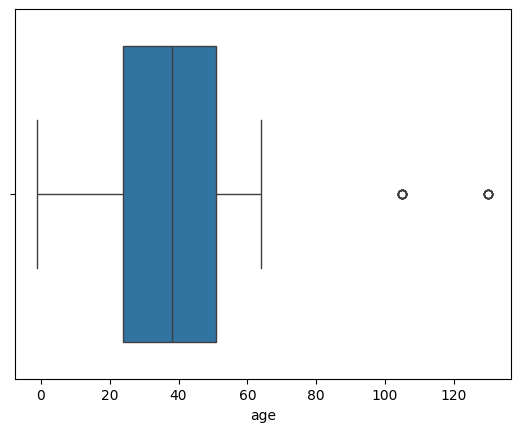

In [ ]:
sns.boxplot(x=df_clean['age'])


**IQR-Based Trimming Method**

In [ ]:
Q1 = df_clean['age'].quantile(0.25)
Q3 = df_clean['age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

Lower Bound: -16.5, Upper Bound: 91.5


In [ ]:
df_clean = df_clean[(df_clean['age'] >= lower_bound) & (df_clean['age'] <= upper_bound)]

print("\n1. Trimming Result:")
print(df_clean['age'].values)


1. Trimming Result:
[20. 59. 59. ... 46. 34. 44.]


<Axes: xlabel='age'>

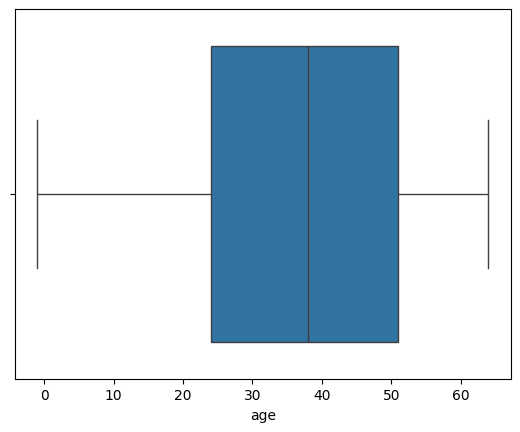

In [ ]:
sns.boxplot(x=df_clean['age'])


**BMI**

<Axes: xlabel='bmi', ylabel='Count'>

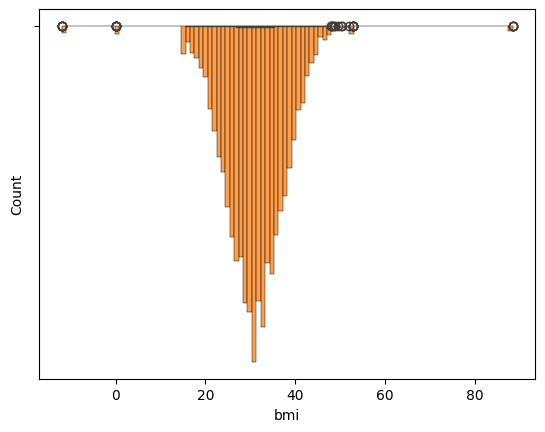

In [ ]:
sns.boxplot(x=df_clean['bmi'])
sns.histplot(df_clean['bmi'])


**Z-Score Based Capping Method**

In [ ]:
mean = df_clean['bmi'].mean()
std = df_clean['bmi'].std()

# 2. Lower aur Upper Bounds set karen (Z-score = 3) yani 3 std away from mean
upper_bound = mean + 3 * std
lower_bound = mean - 3 * std

print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")

Lower Bound: 10.81
Upper Bound: 51.28




> `np.where(condition, if_true, if_false)`

<pre>
IF bmi > upper_bound:
    return upper_bound
ELSE IF bmi < lower_bound:
    return lower_bound
ELSE:
    return original bmi
</pre>

In [ ]:
df_clean['bmi'] = np.where(df_clean['bmi'] > upper_bound, upper_bound, np.where(df_clean['bmi'] < lower_bound, lower_bound, df_clean['bmi']))

<Axes: xlabel='bmi', ylabel='Count'>

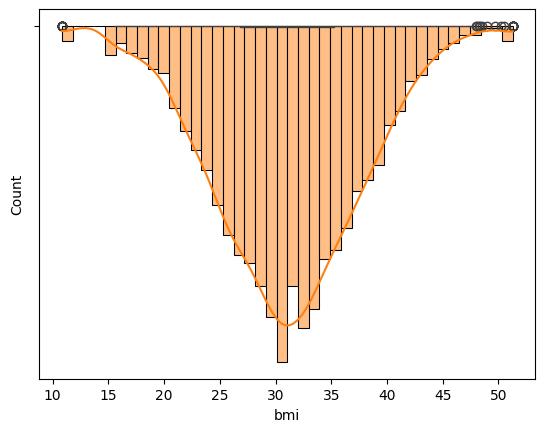

In [ ]:
sns.boxplot(x=df_clean['bmi'])
sns.histplot(df_clean['bmi'], kde=True)


**Charges**

<Axes: xlabel='charges'>

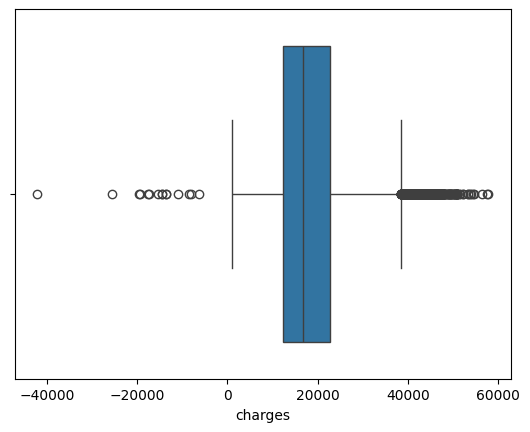

In [ ]:
sns.boxplot(x=df_clean['charges'])
# sns.histplot(df_clean['charges'], kde=True)

**Approach 1: IQR-Based Capping**

In [ ]:
Q1 = df_clean['charges'].quantile(0.25)
Q3 = df_clean['charges'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [ ]:
df_clean['charges'] = np.where(
    df_clean['charges'] > upper_bound, upper_bound,
    np.where(df_clean['charges'] < lower_bound, lower_bound, df_clean['charges'])
)

<Axes: xlabel='charges', ylabel='Count'>

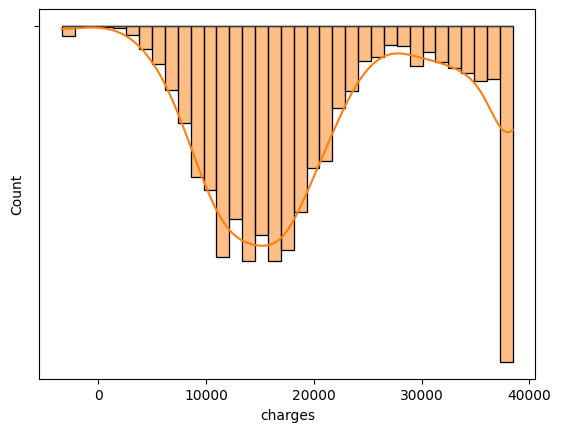

In [ ]:
sns.boxplot(x=df_clean['charges'])
sns.histplot(df_clean['charges'], kde=True)


**Approach 2: Trimming Negative Values + Log Transformation**

> Recommeded for machine learning better results.

In [ ]:
# Trimming negative noise
df_clean = df_clean[df_clean['charges'] > 0]

# Log Transformation
df_clean['charges_log'] = np.log(df_clean['charges'])

<Axes: xlabel='charges_log', ylabel='Count'>

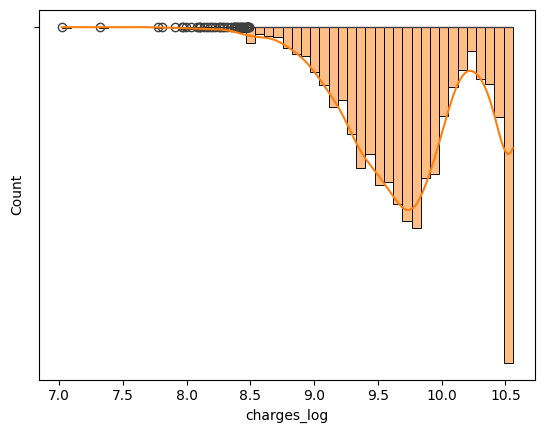

In [ ]:
sns.boxplot(x=df_clean['charges_log'])
sns.histplot(df_clean['charges_log'], kde=True)

**Fix Logic & Domain Errors**

*e.g. negative values handling*

## **Data Preprocessing**

*Encoding Object Data into Numeric Values*

In [ ]:
df_cleaned = df_clean.copy()

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges,charges_log
0,20.0,male,28.619,1,no,southwest,11915.47089,9.385593
1,59.0,male,20.976,5,no,southeast,16904.22892,9.735319
2,59.0,female,29.259,1,no,southeast,21054.85208,9.954886
3,20.0,female,31.071,0,no,northeast,11590.85225,9.357971
4,27.0,female,40.684,0,yes,southwest,36845.73442,10.514495


**Label Encoding**

In [ ]:
df_cleaned['sex'].unique()

array(['male', 'female'], dtype=object)

In [ ]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male': 0, 'female': 1})
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges,charges_log
0,20.0,0,28.619,1,no,southwest,11915.47089,9.385593
1,59.0,0,20.976,5,no,southeast,16904.22892,9.735319
2,59.0,1,29.259,1,no,southeast,21054.85208,9.954886
3,20.0,1,31.071,0,no,northeast,11590.85225,9.357971
4,27.0,1,40.684,0,yes,southwest,36845.73442,10.514495


In [ ]:
df_cleaned['smoker'].value_counts()

,count
smoker,
no,3898
yes,1073


In [ ]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'yes': 1, 'no': 0})
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges,charges_log
0,20.0,0,28.619,1,0,southwest,11915.47089,9.385593
1,59.0,0,20.976,5,0,southeast,16904.22892,9.735319
2,59.0,1,29.259,1,0,southeast,21054.85208,9.954886
3,20.0,1,31.071,0,0,northeast,11590.85225,9.357971
4,27.0,1,40.684,0,1,southwest,36845.73442,10.514495


In [ ]:
df_cleaned.rename(columns={'sex': 'is_female', 'smoker': 'is_smoker'}, inplace=True)

In [ ]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges,charges_log
0,20.0,0,28.619,1,0,southwest,11915.47089,9.385593
1,59.0,0,20.976,5,0,southeast,16904.22892,9.735319
2,59.0,1,29.259,1,0,southeast,21054.85208,9.954886
3,20.0,1,31.071,0,0,northeast,11590.85225,9.357971
4,27.0,1,40.684,0,1,southwest,36845.73442,10.514495


**One Hot Encoding**

In [ ]:
df_cleaned['region'].value_counts()

,count
region,
southeast,1421
northeast,1240
southwest,1171
northwest,1139


In [ ]:
# df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], prefix='region', drop_first=True)
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], prefix='region')
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,charges_log,region_northeast,region_northwest,region_southeast,region_southwest
0,20.0,0,28.619,1,0,11915.47089,9.385593,False,False,False,True
1,59.0,0,20.976,5,0,16904.22892,9.735319,False,False,True,False
2,59.0,1,29.259,1,0,21054.85208,9.954886,False,False,True,False
3,20.0,1,31.071,0,0,11590.85225,9.357971,True,False,False,False
4,27.0,1,40.684,0,1,36845.73442,10.514495,False,False,False,True


It is often said that **`drop_first=True`** removes the original column from the DataFrame, but that's not exactly what happens. The original categorical column is first **transformed into multiple dummy (one-hot encoded) columns.** Then, if **`drop_first=True`** is used, **only the first dummy column is dropped**, not the original column itself, because the original column has already been replaced by the dummy columns.

**Convert True/False into Integers**

In [ ]:
df_cleaned = df_cleaned.astype(int)

In [ ]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,charges_log,region_northeast,region_northwest,region_southeast,region_southwest
0,20,0,28,1,0,11915,9,0,0,0,1
1,59,0,20,5,0,16904,9,0,0,1,0
2,59,1,29,1,0,21054,9,0,0,1,0
3,20,1,31,0,0,11590,9,1,0,0,0
4,27,1,40,0,1,36845,10,0,0,0,1


## **Feature Engineering**

*Explore the existing columns and extract meaningful information into new features. Then, experiment with different combinations of these features by adding, removing, or transforming columns to determine which set improves the model's performance the most.*

**Existing columns se intelligent aur meaningful naye columns banana.**


> **During Feature Engineering, never modify the target variable (Charges). Perform all transformations only on the input features.**

In [ ]:
df_encoded = df_cleaned.copy()

<Axes: xlabel='bmi', ylabel='Count'>

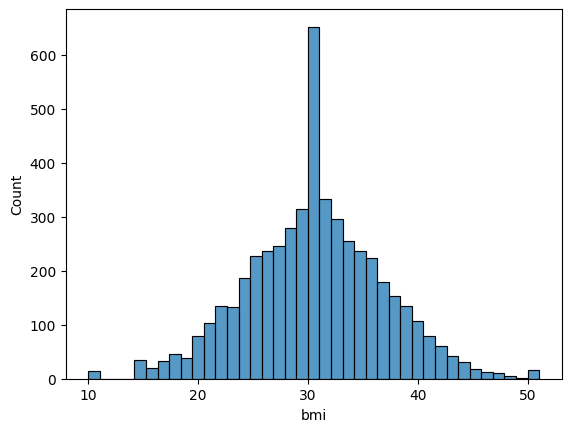

In [ ]:
sns.histplot(df_encoded['bmi'])

I have searched on google about `BMI Categories` and got this:
- Underweight: BMI less than 18.5
- Healthy weight: BMI 18.5 to 24.9
- Overweight: BMI 25.0 to 29.9
- Obesity (Class 1): BMI 30.0 to 34.9
- Obesity (Class 2): BMI 35.0 to 39.9
- Severe Obesity (Class 3): BMI 40.0 or higher

Now on the basis of these i can extract features

**`pd.cut(x_column, bins, labels=None, right=True)`**

In [ ]:
df_encoded['bmi_category'] = pd.cut(
    df_encoded['bmi'],
    bins = [0, 18.5, 24.9, 29.9, 34.9, 39.9, 100],
    labels = ['Underweight', 'Healthy Weight', 'Overweight', 'Obesity (Class 1)', 'Obesity (Class 2)', 'Severe Obesity (Class 3)']
)


In [ ]:
df_encoded.head()

,age,is_female,bmi,children,is_smoker,charges,charges_log,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,20,0,28,1,0,11915,9,0,0,0,1,Overweight
1,59,0,20,5,0,16904,9,0,0,1,0,Healthy Weight
2,59,1,29,1,0,21054,9,0,0,1,0,Overweight
3,20,1,31,0,0,11590,9,1,0,0,0,Obesity (Class 1)
4,27,1,40,0,1,36845,10,0,0,0,1,Severe Obesity (Class 3)


In [ ]:
df_encoded['bmi_category'].value_counts()

,count
bmi_category,
Obesity (Class 1),1536
Overweight,1301
Obesity (Class 2),928
Healthy Weight,675
Severe Obesity (Class 3),382
Underweight,149


In [ ]:
# df_encoded =df_encoded.drop(columns=['bmi_category'])

In [ ]:
df_encoded = pd.get_dummies(df_encoded, columns=['bmi_category'], prefix='bmi')

In [ ]:
df_encoded = df_encoded.astype(int)

In [ ]:
df_encoded.head()

,age,is_female,bmi,children,is_smoker,charges,charges_log,region_northeast,region_northwest,region_southeast,region_southwest,bmi_Underweight,bmi_Healthy Weight,bmi_Overweight,bmi_Obesity (Class 1),bmi_Obesity (Class 2),bmi_Severe Obesity (Class 3)
0,20,0,28,1,0,11915,9,0,0,0,1,0,0,1,0,0,0
1,59,0,20,5,0,16904,9,0,0,1,0,0,1,0,0,0,0
2,59,1,29,1,0,21054,9,0,0,1,0,0,0,1,0,0,0
3,20,1,31,0,0,11590,9,1,0,0,0,0,0,0,1,0,0
4,27,1,40,0,1,36845,10,0,0,0,1,0,0,0,0,0,1


## **Feature Scaling**

*Feature Scaling changes the scale (range) of numerical features without changing the relationships between the data points.*

#### One-line Rule

> **If an algorithm compares distances or updates weights using optimization, perform feature scaling. If it is tree-based, scaling is generally unnecessary.**

| Algorithm Type                    | Feature Scaling | Why?                                                                                                     |
| --------------------------------- | --------------- | -------------------------------------------------------------------------------------------------------- |
| **KNN (K-Nearest Neighbors)**     | Required        | Uses distance (Euclidean/Manhattan).                                                                     |
| **K-Means**                       | Required        | Distance-based clustering.                                                                               |
| **SVM**                           | Required        | Distance and optimization-based.                                                                         |
| **Logistic Regression**           | Recommended     | Gradient descent converges faster and coefficients become more stable.                                   |
| **Linear Regression**             | Optional        | Not required for correctness, but recommended if using gradient descent or regularization (Lasso/Ridge). |
| **Neural Networks**               | Required        | Faster and more stable training.                                                                         |
| **Naive Bayes**                   | Not Required    | Uses probabilities, not distances.                                                                       |
| **Decision Tree**                 | Not Required    | Splits based on feature values, not distances.                                                           |
| **Random Forest**                 | Not Required    | Collection of decision trees.                                                                            |
| **XGBoost / LightGBM / CatBoost** | Not Required    | Tree-based algorithms.                                                                                   |

#### Easy Trick to Remember

* **Distance-based algorithms → Scaling is Required**

  * KNN
  * K-Means
  * SVM

* **Gradient-based algorithms → Scaling is Recommended/Usually Required**

  * Logistic Regression
  * Neural Networks
  * Linear Regression (especially with Gradient Descent, Ridge, or Lasso)

* **Tree-based algorithms → Scaling is Not Required**

  * Decision Tree
  * Random Forest
  * XGBoost
  * LightGBM
  * CatBoost


> Feature scaling depends on the model being used, not on whether the task is regression or classification.This is often done for convenience and consistency.

In [ ]:
df_extracted = df_encoded.copy()

In [ ]:
df_extracted.head()

,age,is_female,bmi,children,is_smoker,charges,charges_log,region_northeast,region_northwest,region_southeast,region_southwest,bmi_Underweight,bmi_Healthy Weight,bmi_Overweight,bmi_Obesity (Class 1),bmi_Obesity (Class 2),bmi_Severe Obesity (Class 3)
0,20,0,28,1,0,11915,9,0,0,0,1,0,0,1,0,0,0
1,59,0,20,5,0,16904,9,0,0,1,0,0,1,0,0,0,0
2,59,1,29,1,0,21054,9,0,0,1,0,0,0,1,0,0,0
3,20,1,31,0,0,11590,9,1,0,0,0,0,0,0,1,0,0
4,27,1,40,0,1,36845,10,0,0,0,1,0,0,0,0,0,1


In [ ]:
df_extracted = df_extracted.drop(columns=['charges_log'])

In [ ]:
df_extracted.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_Underweight', 'bmi_Healthy Weight',
       'bmi_Overweight', 'bmi_Obesity (Class 1)', 'bmi_Obesity (Class 2)',
       'bmi_Severe Obesity (Class 3)'],
      dtype='object')

Select **numerical feature columns (excluding the target variable) that are on different scales**, then apply an appropriate **feature scaling technique (MinMaxScaler, StandardScaler, or RobustScaler)** based on the **data distribution** and the **presence of outliers**.

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

#### Scaler Types

| Scaler             | Output Range                                                        | Best Used When                                  |
| ------------------ | ------------------------------------------------------------------- | ----------------------------------------------- |
| **MinMaxScaler**   | **0 to 1** (or custom range)                                        | Data has **no significant outliers**.           |
| **StandardScaler** | Mean = **0**, Std = **1**. Most values lie between **-3 and +3**.   | Data is approximately **normally distributed**. |
| **RobustScaler**   | Median = **0**, scaled using **IQR** (Q3 − Q1). **No fixed range.** | Data contains **many outliers**.                |


In [ ]:
df_extracted[['age', 'bmi', 'children']].describe()

,age,bmi,children
count,4971.000000,4971.000000,4971.000000
mean,37.945685,30.567491,1.116073
std,14.815345,6.304483,1.208290
min,-1.000000,10.000000,0.000000
25%,24.000000,26.000000,0.000000
50%,38.000000,31.000000,1.000000
75%,51.000000,35.000000,2.000000
max,64.000000,51.000000,5.000000


In [ ]:
cols = ['age', 'bmi', 'children']
scaler = StandardScaler()


df_extracted[cols] = scaler.fit_transform(df_extracted[cols])

In [ ]:
df_extracted.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_Underweight,bmi_Healthy Weight,bmi_Overweight,bmi_Obesity (Class 1),bmi_Obesity (Class 2),bmi_Severe Obesity (Class 3)
0,-1.211412,0,-0.407290,-0.096074,0,11915,0,0,0,1,0,0,1,0,0,0
1,1.421258,0,-1.676356,3.214723,0,16904,0,0,1,0,0,1,0,0,0,0
2,1.421258,1,-0.248656,-0.096074,0,21054,0,0,1,0,0,0,1,0,0,0
3,-1.211412,1,0.068610,-0.923773,0,11590,1,0,0,0,0,0,0,1,0,0
4,-0.738882,1,1.496310,-0.923773,1,36845,0,0,0,1,0,0,0,0,0,1


## **Feature Extraction & Selection**

**Feature Extraction (e.g., PCA):** Combining multiple original columns (like Length & Width) to **create a single new feature (like Area)** that summarizes their information.


**Feature Selection:** Selecting the best existing features from the dataset while dropping the rest without modifying them.



> Mainly we are focusing on Feature Selection here. Feature Extraction will be discussed later on.

---
#### **Feature Selection using Pearson Correlation**
>
> * **|r| ≥ 0.5** → Strong correlation. **Definitely consider** these features.
> * **0.2 ≤ |r| < 0.5** → Moderate correlation. **Usually consider** these features.
> * **0.1 ≤ |r| < 0.2** → Weak correlation. **Optional**; use **hit-and-trial**. Keep them only if they improve the model's performance (e.g., increase the score to your desired level).
> * **|r| < 0.1** → Very weak correlation. **Generally drop** these features.
>
> **Note:** A feature with a low Pearson correlation is **not necessarily useless**. It may become important when combined with other features through **Feature Engineering**, **Feature Extraction**, or techniques like **PCA**, where multiple features together can capture useful information that a single feature cannot.

**Remember:** Always use the **absolute value** of Pearson correlation (`|r|`). For example, `-0.8` is just as strong a correlation as `+0.8`; only the direction is different.


In [ ]:
from scipy.stats import pearsonr

selected_features = ['age', 'bmi', 'children', 'is_female', 'is_smoker', 'region_northeast',
                 'region_northwest', 'region_southeast', 'region_southwest',
                 'bmi_Healthy Weight', 'bmi_Obesity (Class 1)', 'bmi_Obesity (Class 2)',
                 'bmi_Overweight', 'bmi_Severe Obesity (Class 3)', 'bmi_Underweight']


correlations = {}

for feature in selected_features:
    correlation, _ = pearsonr(df_extracted['charges'], df_extracted[feature])

    # correlation = pearsonr(df_extracted['charges'], df_extracted[feature])[0]

    correlations[feature] = correlation


In [ ]:
correlations.items()

dict_items([('age', np.float64(0.34628718737156605)), ('bmi', np.float64(0.17629180275908757)), ('children', np.float64(0.06019035341587588)), ('is_female', np.float64(-0.002406289720906742)), ('is_smoker', np.float64(0.8705359515848593)), ('region_northeast', np.float64(-0.016597180168915128)), ('region_northwest', np.float64(0.02916746434909209)), ('region_southeast', np.float64(-0.0023160198406944102)), ('region_southwest', np.float64(-0.009497699252659253)), ('bmi_Healthy Weight', np.float64(-0.09692852363773015)), ('bmi_Obesity (Class 1)', np.float64(-0.0029048878155374823)), ('bmi_Obesity (Class 2)', np.float64(0.09690661974735931)), ('bmi_Overweight', np.float64(-0.03658955694089668)), ('bmi_Severe Obesity (Class 3)', np.float64(0.10187087106625133)), ('bmi_Underweight', np.float64(-0.08364766212495221))])

In [ ]:
correlations_df = pd.DataFrame(list(correlations.items()), columns=['Feature','Pearson Corelation with Target Variable'])

correlations_df = correlations_df.sort_values(by='Pearson Corelation with Target Variable', ascending=False).reset_index()

In [ ]:
correlations_df

,index,Feature,Pearson Corelation with Target Variable
0,4,is_smoker,0.870536
1,0,age,0.346287
2,1,bmi,0.176292
3,13,bmi_Severe Obesity (Class 3),0.101871
4,11,bmi_Obesity (Class 2),0.096907
5,2,children,0.060190
6,6,region_northwest,0.029167
7,7,region_southeast,-0.002316
8,3,is_female,-0.002406
9,10,bmi_Obesity (Class 1),-0.002905


Here, Pearson correlation is used on all input features (numerical and encoded categorical). However, Pearson works best for numerical features. For categorical features, the Chi-Square Test is usually a better choice to understand their relationship with the target variable.

**Chi Square Test**

The Chi-Square Test is used to measure the relationship between two categorical variables. Since our target variable (Charges) is continuous (numerical), we first convert it into categories by creating bins. Then, we can use the Chi-Square Test to check the relationship between each categorical feature and the binned target variable

In [ ]:
cat_features = ['is_female', 'is_smoker', 'region_northeast', 'region_northwest', 'region_southeast',
                'region_southwest', 'bmi_Healthy Weight', 'bmi_Obesity (Class 1)', 'bmi_Obesity (Class 2)',
                'bmi_Overweight', 'bmi_Severe Obesity (Class 3)', 'bmi_Underweight']

<Axes: xlabel='charges', ylabel='Count'>

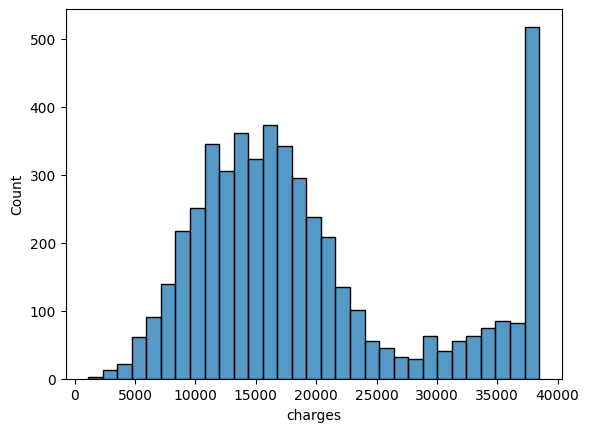

In [ ]:
sns.histplot(df_extracted['charges'])

In [ ]:
# df_extracted['charges_bin'] = pd.qcut(df_extracted['charges'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
df_extracted['charges_bin'] = pd.qcut(df_extracted['charges'], q=4, labels=False)

In [ ]:
df_extracted.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_Underweight,bmi_Healthy Weight,bmi_Overweight,bmi_Obesity (Class 1),bmi_Obesity (Class 2),bmi_Severe Obesity (Class 3),charges_bin
0,-1.211412,0,-0.407290,-0.096074,0,11915,0,0,0,1,0,0,1,0,0,0,0
1,1.421258,0,-1.676356,3.214723,0,16904,0,0,1,0,0,1,0,0,0,0,2
2,1.421258,1,-0.248656,-0.096074,0,21054,0,0,1,0,0,0,1,0,0,0,2
3,-1.211412,1,0.068610,-0.923773,0,11590,1,0,0,0,0,0,0,1,0,0,0
4,-0.738882,1,1.496310,-0.923773,1,36845,0,0,0,1,0,0,0,0,0,1,3


In [ ]:
from scipy.stats import chi2_contingency

alpha = 0.05

# Is there difference between them

chi2_results = {}


for col in cat_features:
  contengency_table = pd.crosstab(df_extracted[col], df_extracted['charges_bin'])

  # chi2, p_val, dof, expected = chi2_contingency(contengency_table)
  chi2, p_val, _, _ = chi2_contingency(contengency_table)


  if p_val <= alpha:
    decision = 'Reject Null Hypothesis (Keep Feature - Significance)'
  else:
    decision = 'Accept Null Hypothesis (Drop Feature -  No Significance)'


  chi2_results[col] = {
      'Chi-Square Statistic': chi2,
      'P-Value': p_val,
      'Decision': decision
  }


In [ ]:
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='P-Value', ascending=True)
chi2_df

,Chi-Square Statistic,P-Value,Decision
is_smoker,3942.650771,0.0,Reject Null Hypothesis (Keep Feature - Signifi...
bmi_Healthy Weight,116.211462,0.0,Reject Null Hypothesis (Keep Feature - Signifi...
bmi_Obesity (Class 2),113.950661,0.0,Reject Null Hypothesis (Keep Feature - Signifi...
bmi_Severe Obesity (Class 3),100.438369,0.0,Reject Null Hypothesis (Keep Feature - Signifi...
bmi_Underweight,70.549371,0.0,Reject Null Hypothesis (Keep Feature - Signifi...
bmi_Overweight,25.711269,0.000011,Reject Null Hypothesis (Keep Feature - Signifi...
bmi_Obesity (Class 1),8.391895,0.03857,Reject Null Hypothesis (Keep Feature - Signifi...
region_northwest,6.116909,0.106059,Accept Null Hypothesis (Drop Feature - No Sig...
region_northeast,3.501916,0.320514,Accept Null Hypothesis (Drop Feature - No Sig...
region_southwest,0.869461,0.832791,Accept Null Hypothesis (Drop Feature - No Sig...


*keep only selected features in new dataframe.*

In [ ]:
df_extracted.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_Underweight', 'bmi_Healthy Weight',
       'bmi_Overweight', 'bmi_Obesity (Class 1)', 'bmi_Obesity (Class 2)',
       'bmi_Severe Obesity (Class 3)', 'charges_bin'],
      dtype='object')

In [ ]:
df_selected = df_extracted[['age', 'bmi', 'children', 'is_smoker',  'bmi_Underweight', 'bmi_Healthy Weight',
       'bmi_Overweight', 'bmi_Obesity (Class 1)', 'bmi_Obesity (Class 2)',
       'bmi_Severe Obesity (Class 3)', 'charges']]

In [ ]:
final_data = df_selected.copy()

In [ ]:
final_data.head()

,age,bmi,children,is_smoker,bmi_Underweight,bmi_Healthy Weight,bmi_Overweight,bmi_Obesity (Class 1),bmi_Obesity (Class 2),bmi_Severe Obesity (Class 3),charges
0,-1.211412,-0.407290,-0.096074,0,0,0,1,0,0,0,11915
1,1.421258,-1.676356,3.214723,0,0,1,0,0,0,0,16904
2,1.421258,-0.248656,-0.096074,0,0,0,1,0,0,0,21054
3,-1.211412,0.068610,-0.923773,0,0,0,0,1,0,0,11590
4,-0.738882,1.496310,-0.923773,1,0,0,0,0,0,1,36845


In [ ]:
final_data.to_csv('insurance_final_data.csv', index=False)